##### Import the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

##### Load the datasets

In [2]:
cardiology = pd.read_csv(r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Data\TimeSeries\Cardiology_Ward_TimeSeries.csv")

In [3]:
cardiology.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3655 entries, 0 to 3654
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   hospital_id     3655 non-null   object 
 1   datetime        3655 non-null   object 
 2   ward            3655 non-null   object 
 3   occupied_beds   3655 non-null   float64
 4   staffed_beds    3655 non-null   float64
 5   occupancy_rate  3655 non-null   float64
dtypes: float64(3), object(3)
memory usage: 171.5+ KB


- Run the ADF test for every hospital

In [4]:
cardiology["hospital_id"].unique()

array(['HHN-BIR-01', 'HHN-EDI-01', 'HHN-LON-01', 'HHN-LON-02',
       'HHN-MAN-01'], dtype=object)

In [5]:
results = []

for hospital in cardiology["hospital_id"].unique():
    hospital_data = (cardiology[cardiology["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    adf = adfuller(hospital_data["occupied_beds"])
    results.append({"Hospital": hospital, "ADF Statistic": round(adf[0],4), "p-value": round(adf[1],4), 
                    "Stationary": "Yes" if adf[1] < 0.05 else "No"})

adf_results = pd.DataFrame(results)

print(f"ADF Test Results for Cardiology Unit Occupied Beds")
adf_results

ADF Test Results for Cardiology Unit Occupied Beds


,Hospital,ADF Statistic,p-value,Stationary
0,HHN-BIR-01,-6.1871,0.0000,Yes
1,HHN-EDI-01,-7.6451,0.0000,Yes
2,HHN-LON-01,-3.1011,0.0265,Yes
3,HHN-LON-02,-4.8174,0.0001,Yes
4,HHN-MAN-01,-4.7023,0.0001,Yes


      All five cardiology wards were found to be stationary, confirming stable occupancy patterns over time.
      All ADF test p-values were below 0.05, indicating no significant long-term drift in bed demand.
      The results confirm that differencing is not required for forecasting (d = 0).
      The original occupancy data can be used directly for ARIMA/SARIMA modelling.
     

- Autocorrelation (ACF) for all hospitals

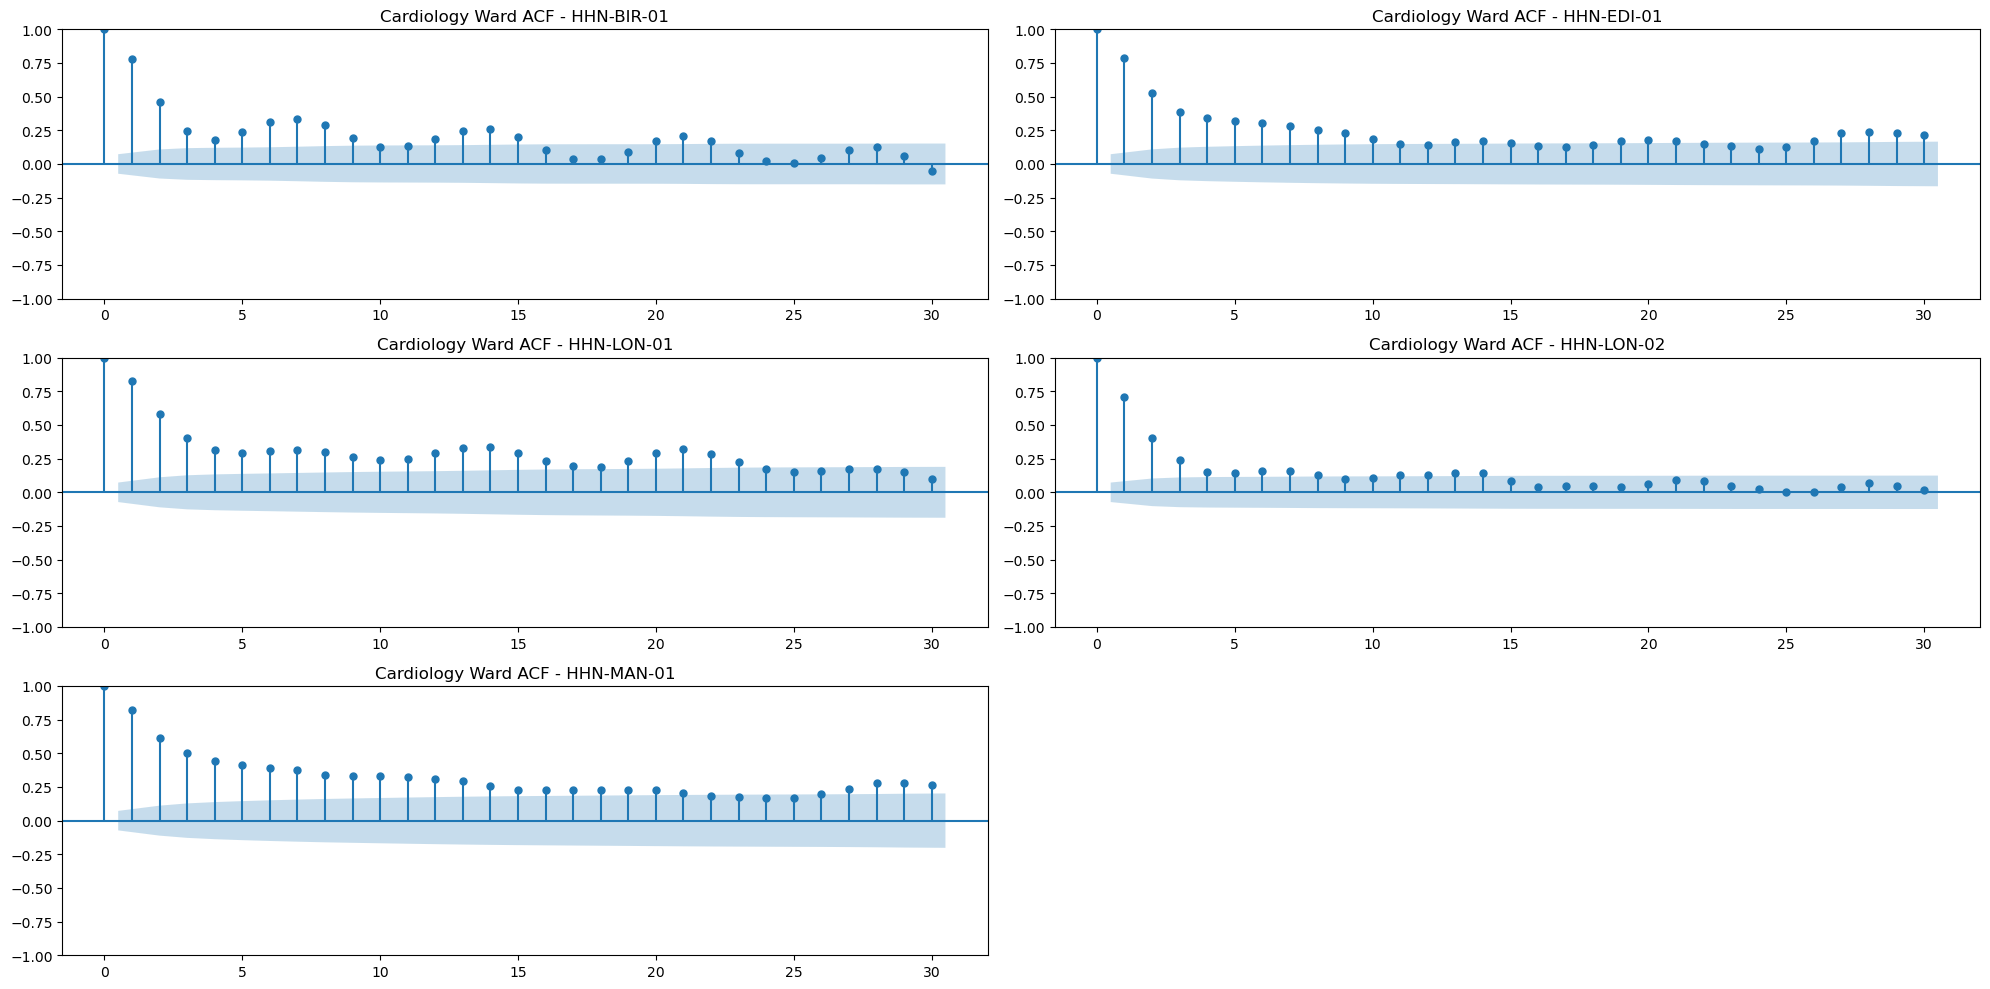

In [ ]:
# Create subplots
fig, axes = plt.subplots(3, 2, figsize=(20, 15))
axes = axes.flatten()

# Loop through hospitals
for i, hospital in enumerate(sorted(cardiology["hospital_id"].unique())):

    hospital_data = (cardiology[cardiology["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    plot_acf(hospital_data["occupied_beds"], lags=30,ax=axes[i])
    axes[i].set_title(f"Cardiology Ward ACF - {hospital}")

# Remove unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

      All cardiology wards showed strong short-term memory, with current bed occupancy highly influenced by the previous 1–2 days.
      The slow decay of autocorrelation indicates multi-day patient stays and persistent occupancy patterns.
      London 2 and Birmingham showed faster memory decay, suggesting higher patient turnover and shorter stays.
      Edinburgh, Manchester, and London 1 showed longer memory effects, reflecting more complex cases and longer admissions.
      Clear weekly seasonal patterns were observed, especially in Birmingham and London 1, linked to scheduled cardiology procedures and weekday activity.
      London 1 showed the strongest demand persistence, indicating prolonged occupancy pressure.
      The ACF results support the use of a SARIMA/SARIMAX model.

- PACF for all hospitals

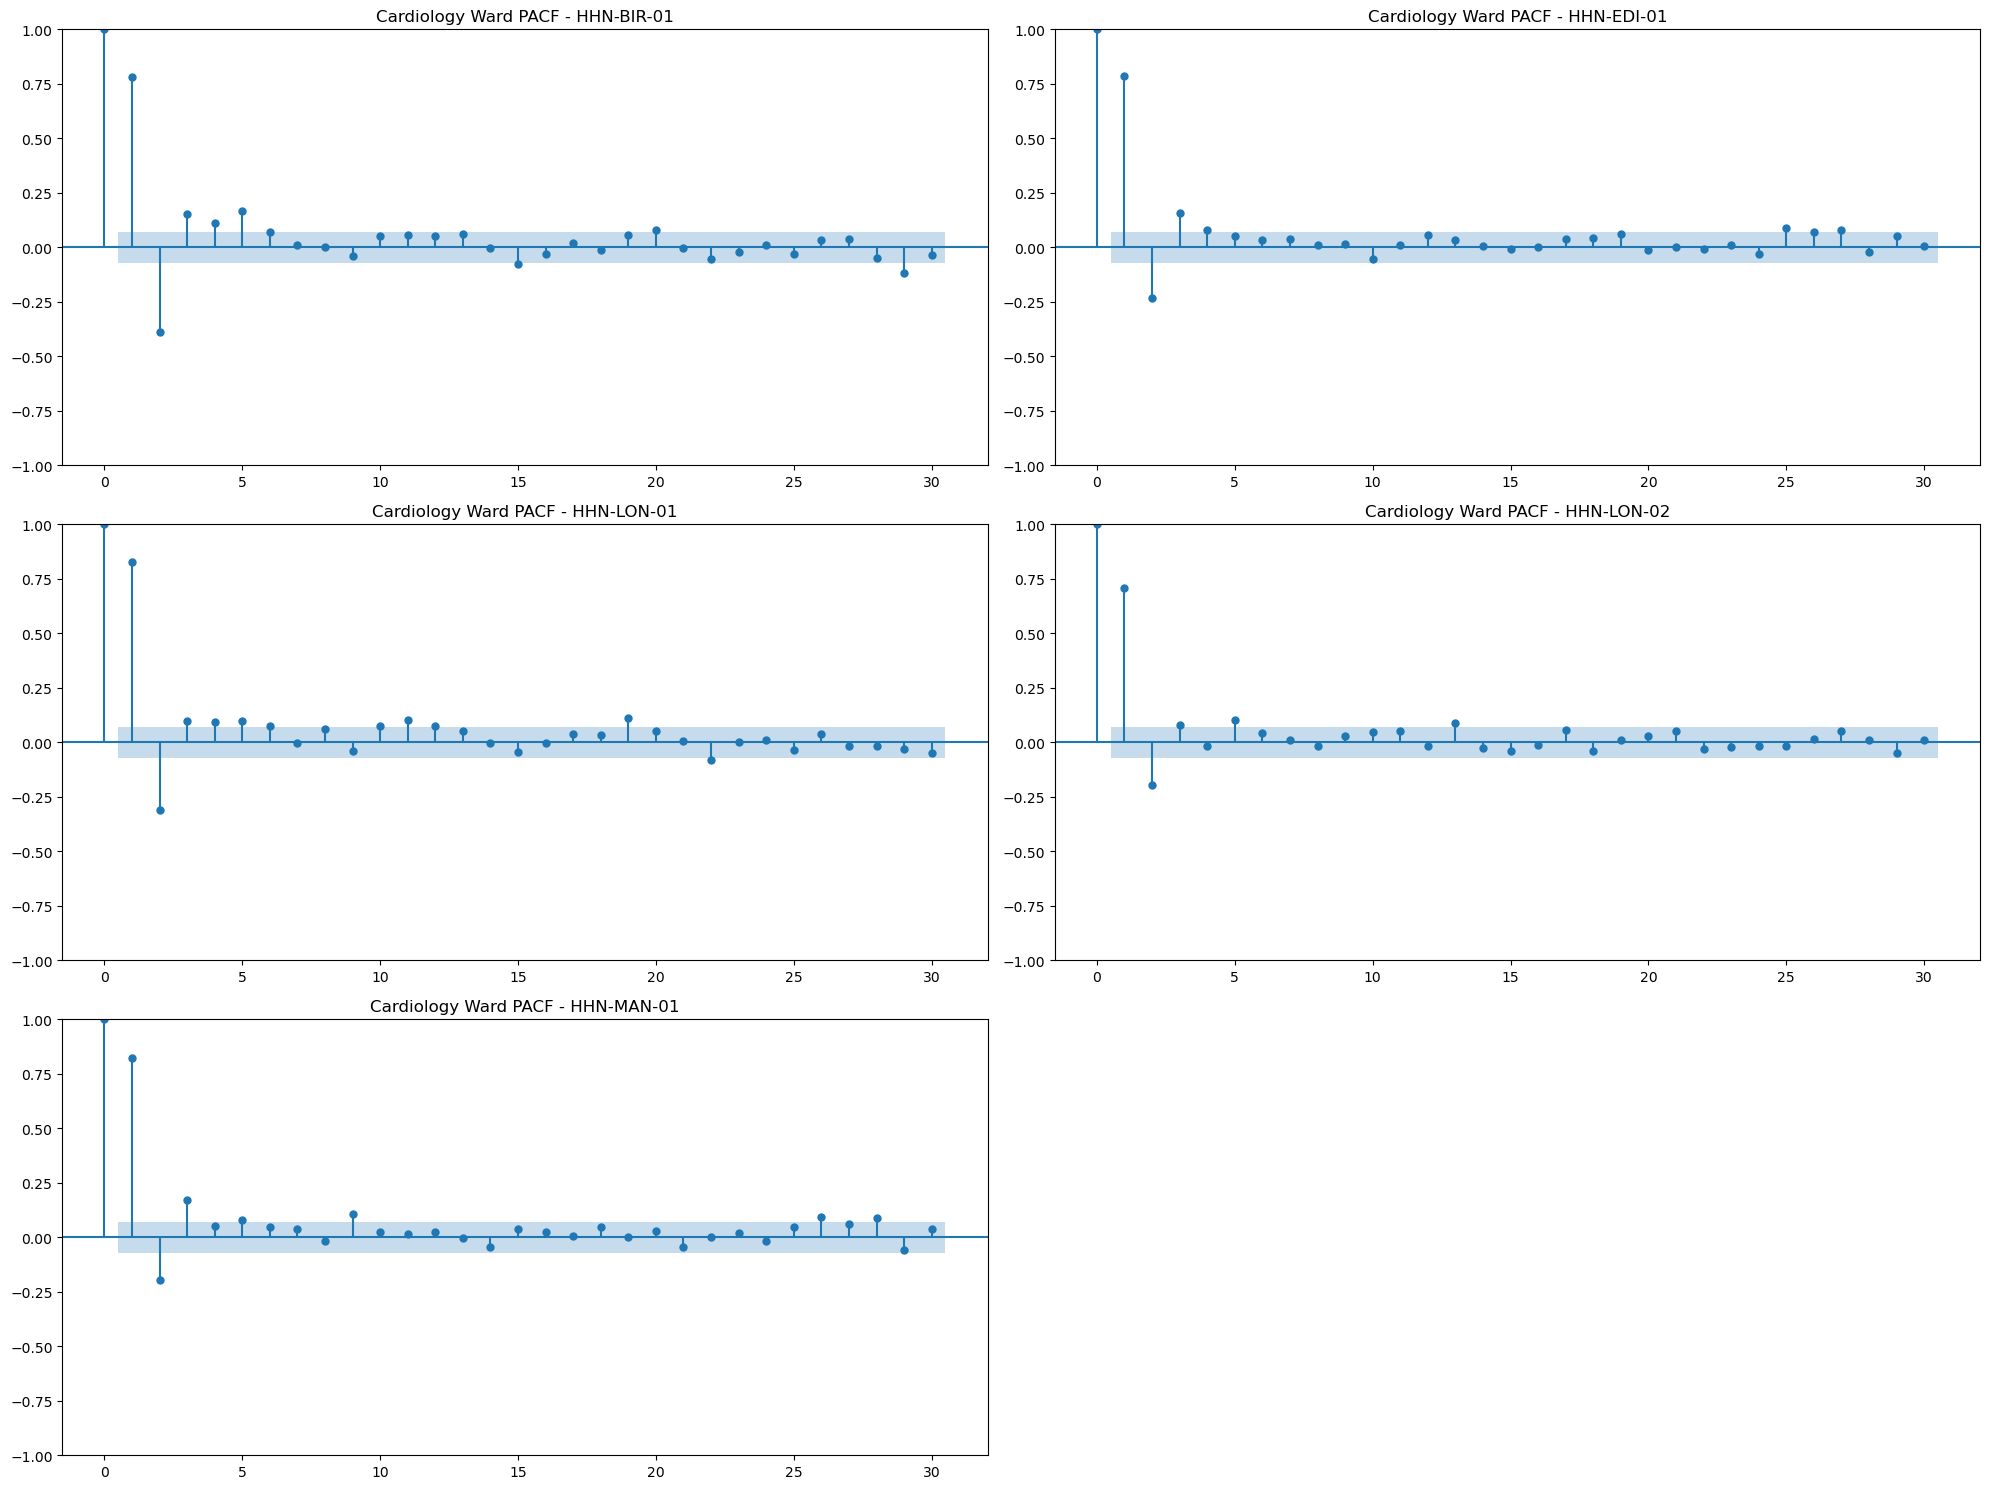

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(20, 15))
axes = axes.flatten()

for i, hospital in enumerate(sorted(cardiology["hospital_id"].unique())):

    hospital_data = (cardiology[cardiology["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    plot_pacf(hospital_data["occupied_beds"], lags=30, ax=axes[i], method="ywm")
    axes[i].set_title(f"Cardiology Ward PACF - {hospital}")
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

      The last two days are the most important factors affecting today's cardiology bed demand.
      Yesterday’s occupancy (Lag 1) has the biggest impact. This means if many beds were occupied yesterday, it is likely that many beds will still be occupied today because cardiology patients usually stay for several days.
      Two days ago (Lag 2) has the opposite effect. This suggests that some patients admitted two days earlier are likely to be discharged today, especially patients staying for short procedures or observation (around 48 hours).
      The results show that cardiology bed demand is mainly affected by: Recent patient admissions and discharges, Short patient recovery periods and Weekly hospital activity patterns.
      Because the data is stable (d = 0) and has a strong two-day memory pattern, a SARIMA model is suitable for forecasting.

- Seasonal Decomposition for all hospitals

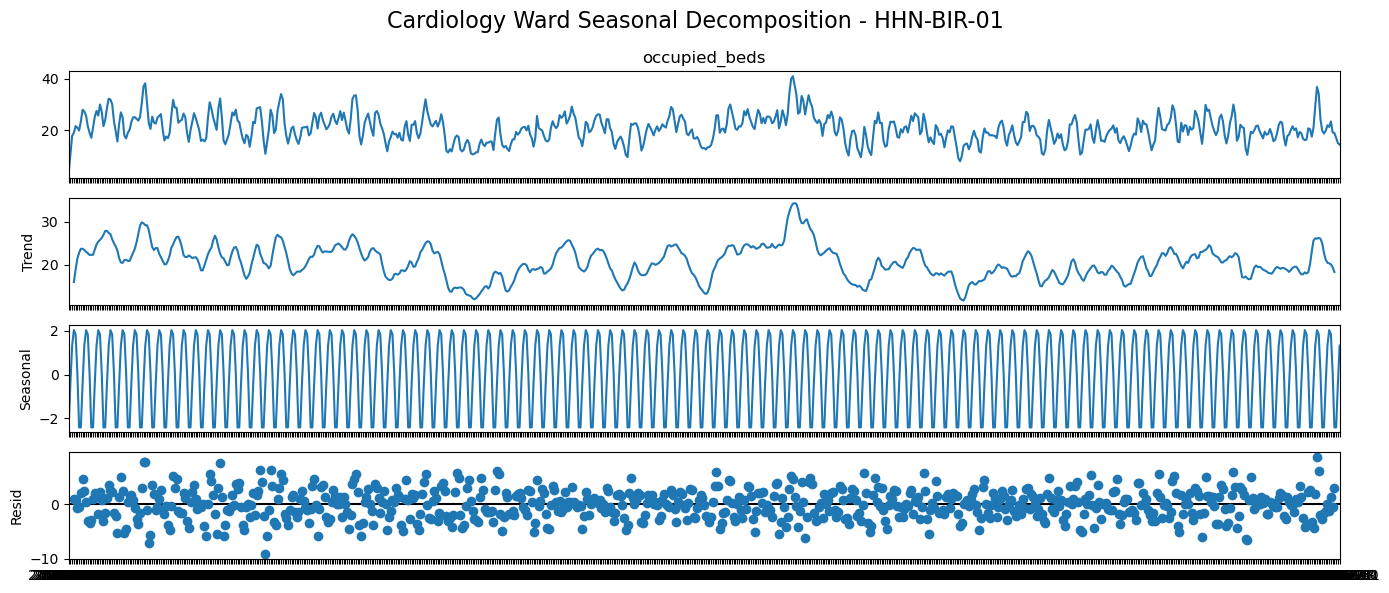

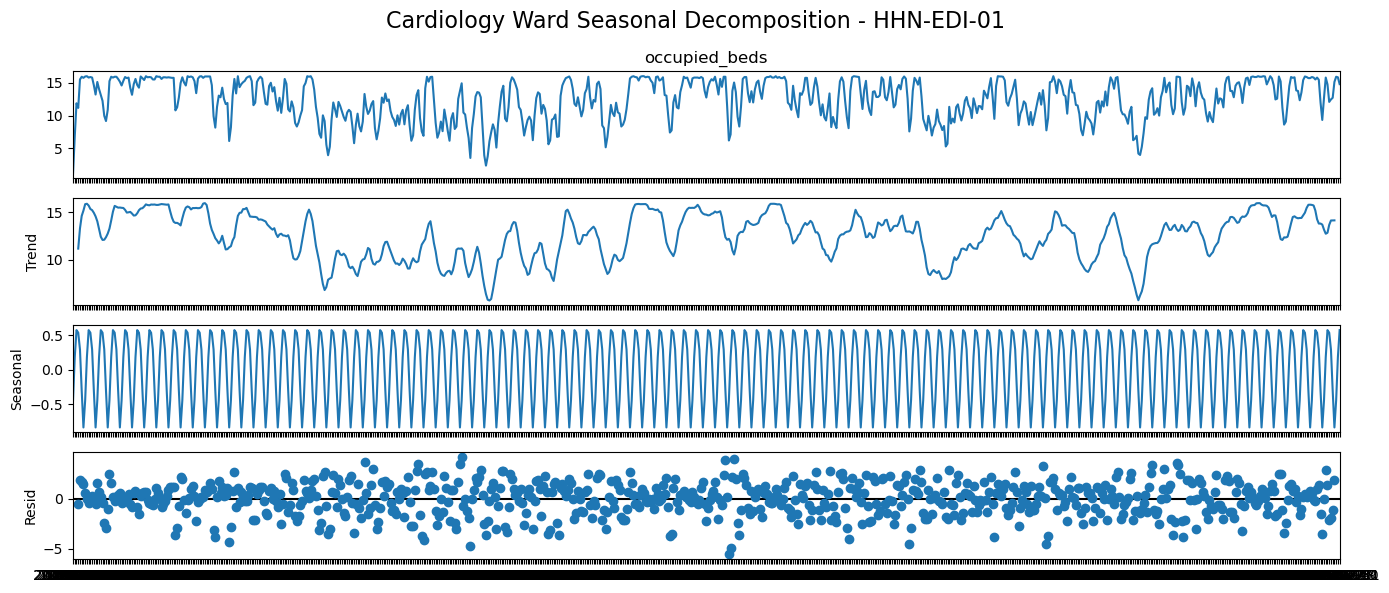

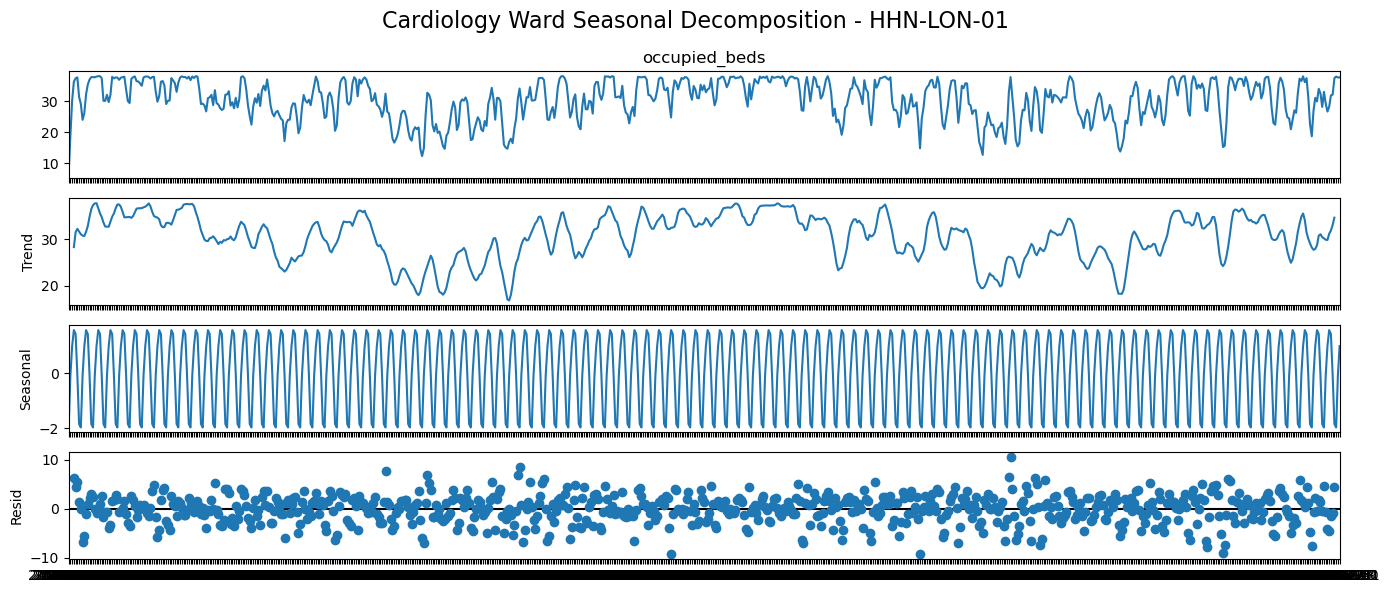

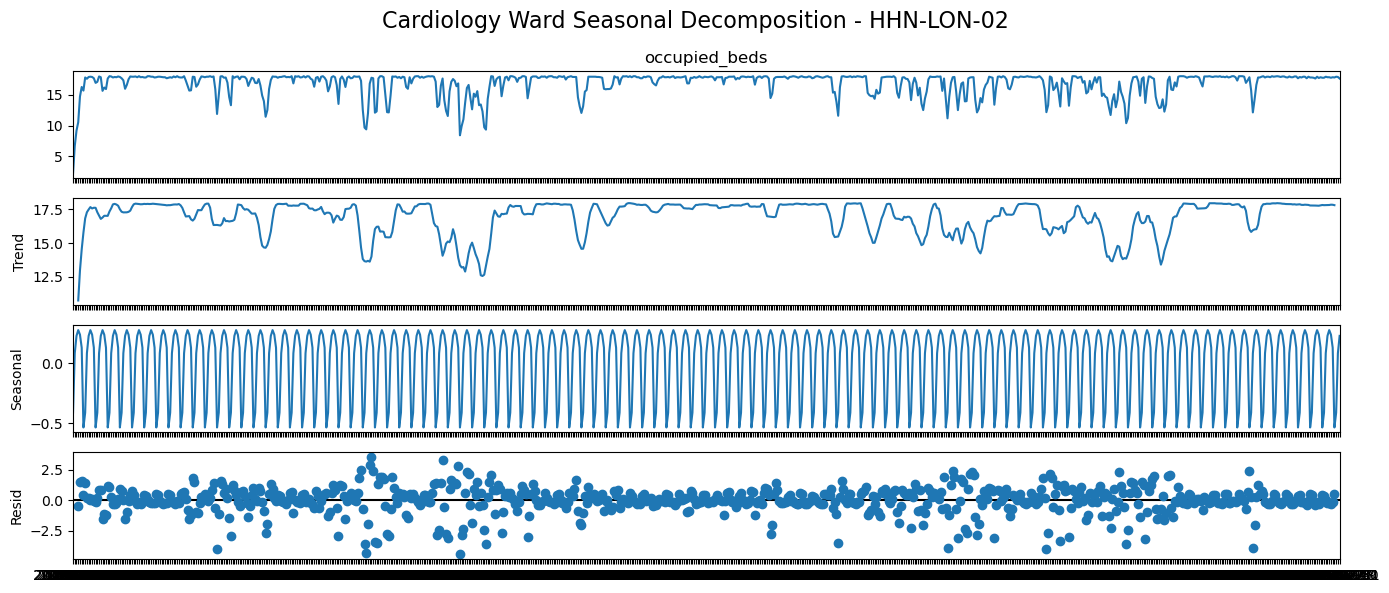

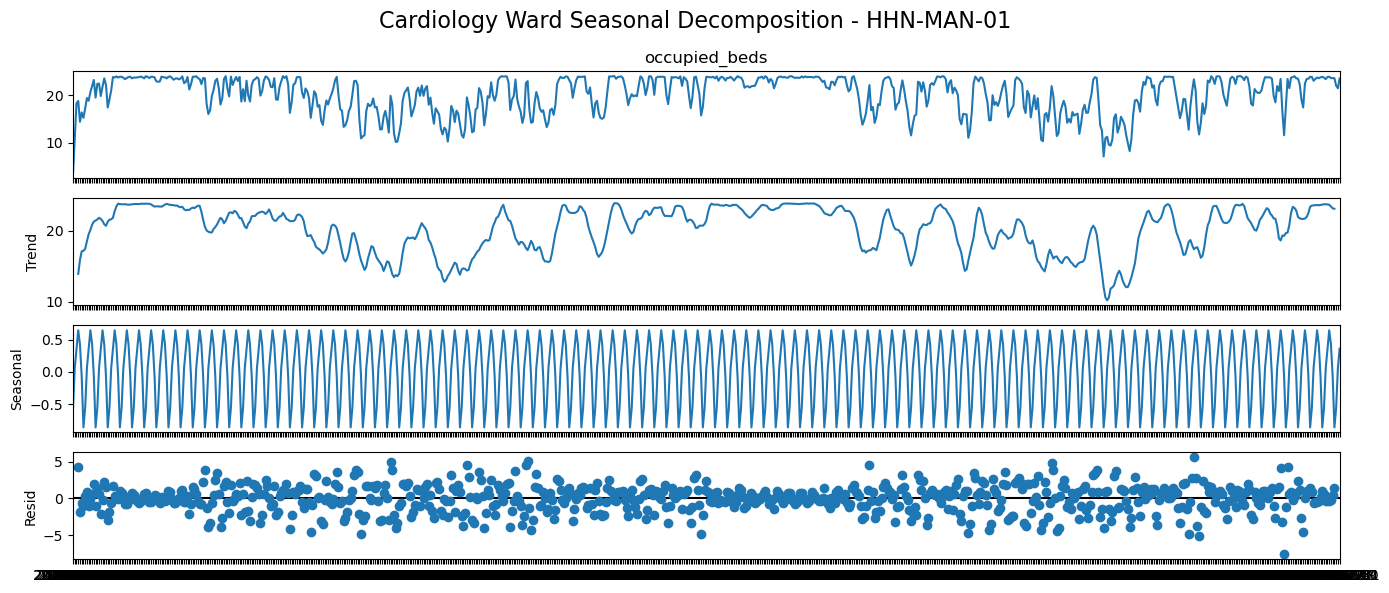

In [8]:
for hospital in sorted(cardiology["hospital_id"].unique()):

    hospital_data = (cardiology[cardiology["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    result = seasonal_decompose(hospital_data["occupied_beds"], model="additive", period=7)
    fig = result.plot()
    fig.set_size_inches(14,6)
    fig.suptitle(f"Cardiology Ward Seasonal Decomposition - {hospital}", fontsize=16)
    plt.tight_layout()
    plt.show()

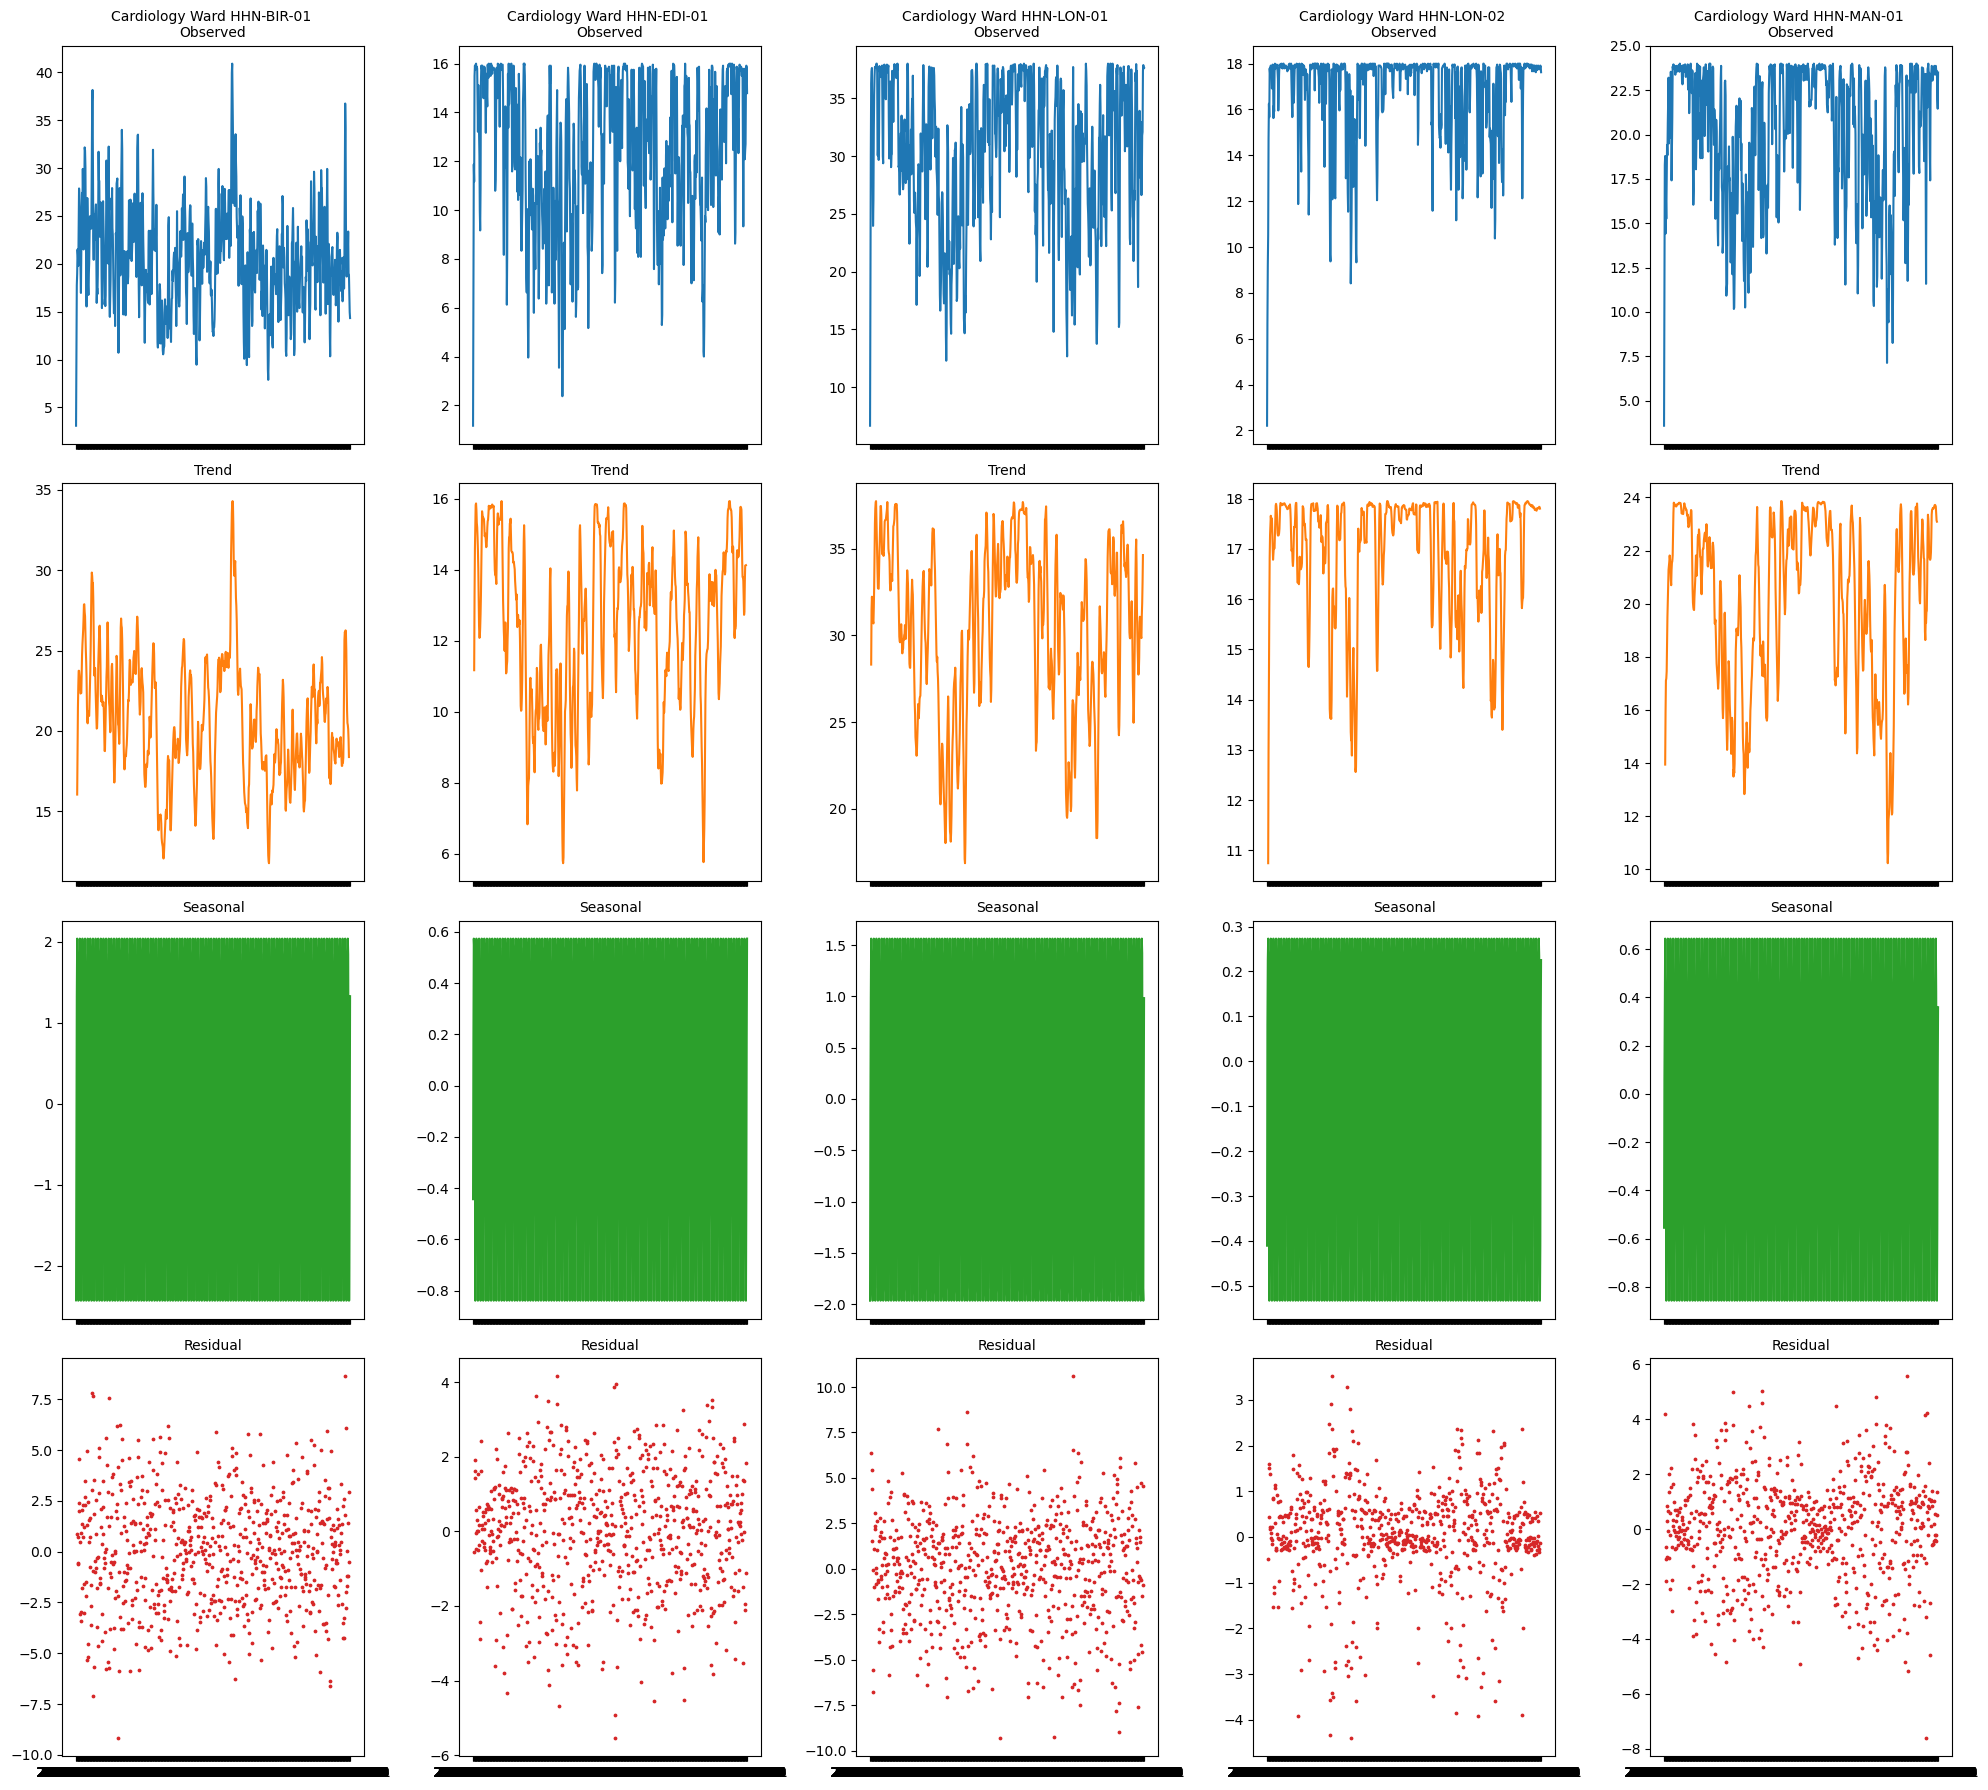

In [9]:
# Create a grid: 4 rows (Observed/Trend/Season/Resid) by X columns (one per hospital)
fig, axes = plt.subplots(4, 5, figsize=(20, 18), sharex=True)

hospitals = sorted(cardiology["hospital_id"].unique())
for col_idx, hospital in enumerate(hospitals):
    # Filter and decompose data
    hospital_data = cardiology[cardiology["hospital_id"] == hospital].sort_values("datetime").set_index("datetime")
    result = seasonal_decompose(hospital_data["occupied_beds"], model="additive", period=7)
    
    # Manually plot each layer into its specific column cell
    axes[0, col_idx].plot(result.observed, color='tab:blue')
    axes[0, col_idx].set_title(f"Cardiology Ward {hospital} \nObserved", fontsize=10)
    
    axes[1, col_idx].plot(result.trend, color='tab:orange')
    axes[1, col_idx].set_title("Trend", fontsize=10)
    
    axes[2, col_idx].plot(result.seasonal, color='tab:green')
    axes[2, col_idx].set_title("Seasonal", fontsize=10)
    
    axes[3, col_idx].scatter(result.resid.index, result.resid, color='tab:red', s=3)
    axes[3, col_idx].set_title("Residual", fontsize=10)

plt.tight_layout()
plt.show()


      Cardiology wards have different bed capacities across hospitals, with London 1 and Birmingham having the most beds.
      Some wards, especially Edinburgh, London 2, and Manchester, often reach full capacity, showing pressure on available beds.
      Bed occupancy changes over time because of both emergency heart cases and planned cardiac procedures.
      A clear weekly pattern was found, with occupancy changing depending on the day of the week.
      Larger hospitals showed bigger weekly changes because they handle more planned procedures.
      The analysis showed that most occupancy patterns were explained by trends and weekly cycles, with only small random changes remaining.
      Some wards have strict capacity limits, meaning demand can be higher than available beds.
      A SARIMA/SARIMAX model is suitable for forecasting cardiology bed demand because it can capture recent occupancy patterns and weekly changes.
